# RAG agent with LangChain

Retrieval-Augmented Generation (RAG) combines a retriever (vector search over documents) with a generator (LLM). Instead of relying only on the LLM's parametric memory, RAG fetches relevant documents at query time and conditions the model on that external context to produce more factual, up-to-date, and grounded responses.

- **Core components:** retriever (embeddings + vector DB), document store, prompt/template, and LLM (generator).
- **Flow:** embed query → retrieve top-K docs → build prompt with retrieved context → generate answer.
- **Benefits:** reduces hallucinations, supports up-to-date knowledge, scales to large corpora.
- **Trade-offs:** added latency, dependency on retrieval quality, storage/cost for embeddings, prompt engineering required.
- **LangChain tips:** index documents with embeddings (e.g., OpenAI/other), use a `RetrievalQA` or `ConversationalRetrievalChain`, tune `k` and prompt templates, and include source attribution where possible.

Quick example (conceptual): create embeddings → store in vector DB → `retriever = vectordb.as_retriever()` → `chain = RetrievalQA.from_chain_type(llm, retriever)` → `chain.run(query)`


**Application Examples** 

- Enterprise search: Answer employee queries over internal docs with source links and excerpts.
- Customer support: Retrieve KB articles and generate grounded responses with citations.
- Legal / compliance research: Fetch statutes/case text and summarize with precise citations.
- Healthcare summarization: Pull guidelines and patient notes to produce contextual summaries (handle PHI securely).
- Codebase assistant: Search repo docs + code, return relevant snippets and suggested fixes.
- Education / tutoring: Retrieve textbook sections and generate explanations, examples, or quizzes.

We will cover the following concepts:
- **Indexing**: a pipeline for ingesting data from a source and indexing it. This usually happens in a separate process.
- **Retrieval and generation** : the actual RAG process, which takes the user query at run time and retrieves the relevant data from the index, then passes that to the model.

In [ ]:
# setup
!pip install langchain langchain-text-splitters langchain-community bs4

In [ ]:
# Langsmith setup (optional, for tracking) 
# import getpass
# import os

# # incompleted !
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_API_KEY"] = getpass.getpass()

In [ ]:
# environment variables
import os
from dotenv import load_dotenv
load_dotenv()
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")
BASE_URL = os.getenv("MODEL_BASE_URL")

## Components 

Select a chat model : 

In [ ]:
# selecting chat model
!pip install -U "langchain[openai]" 

In [6]:
# using model class
import os
from langchain_openai import ChatOpenAI


model = ChatOpenAI(model="gpt-4.1",base_url = BASE_URL,api_key = GITHUB_TOKEN )

Select an embeddings model:

In [ ]:
# -qU flags for quitley update(if installed or install, means in less output)
!pip install -qU langchain-huggingface

In [5]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

Select a vector store:

In [ ]:
!pip install -qU langchain-chroma

In [ ]:
from langchain_chroma import Chroma

vector_store = Chroma(
    collection_name="rag_sample_docs",
    embedding_function=embeddings,
    persist_directory="../local_chromaDb/", # local directory where data stored
)

## Indexing 


The indexing process consists of three main steps:

### 1. **Load**
- Use **Document Loaders** to load data from sources
- Example: `WebBaseLoader` loads HTML from web URLs and parses it to text using BeautifulSoup
- Can customize parsing by specifying which HTML elements to keep

### 2. **Split**
- Use **Text Splitters** to break large documents into smaller chunks
- Recommended: `RecursiveCharacterTextSplitter` for generic text
- Configuration options:
  - `chunk_size`: Size of each chunk (in characters)
  - `chunk_overlap`: Overlap between chunks (in characters)
  - `add_start_index`: Track position in original document
- Makes data easier to search and fit within model context windows

### 3. **Store**
- **Embed** document chunks using an embeddings model
- **Store** embeddings in a **Vector Store** for later retrieval
- Enables semantic search over the indexed content
- Example: Use `vector_store.add_documents()` to embed and store all splits in one command


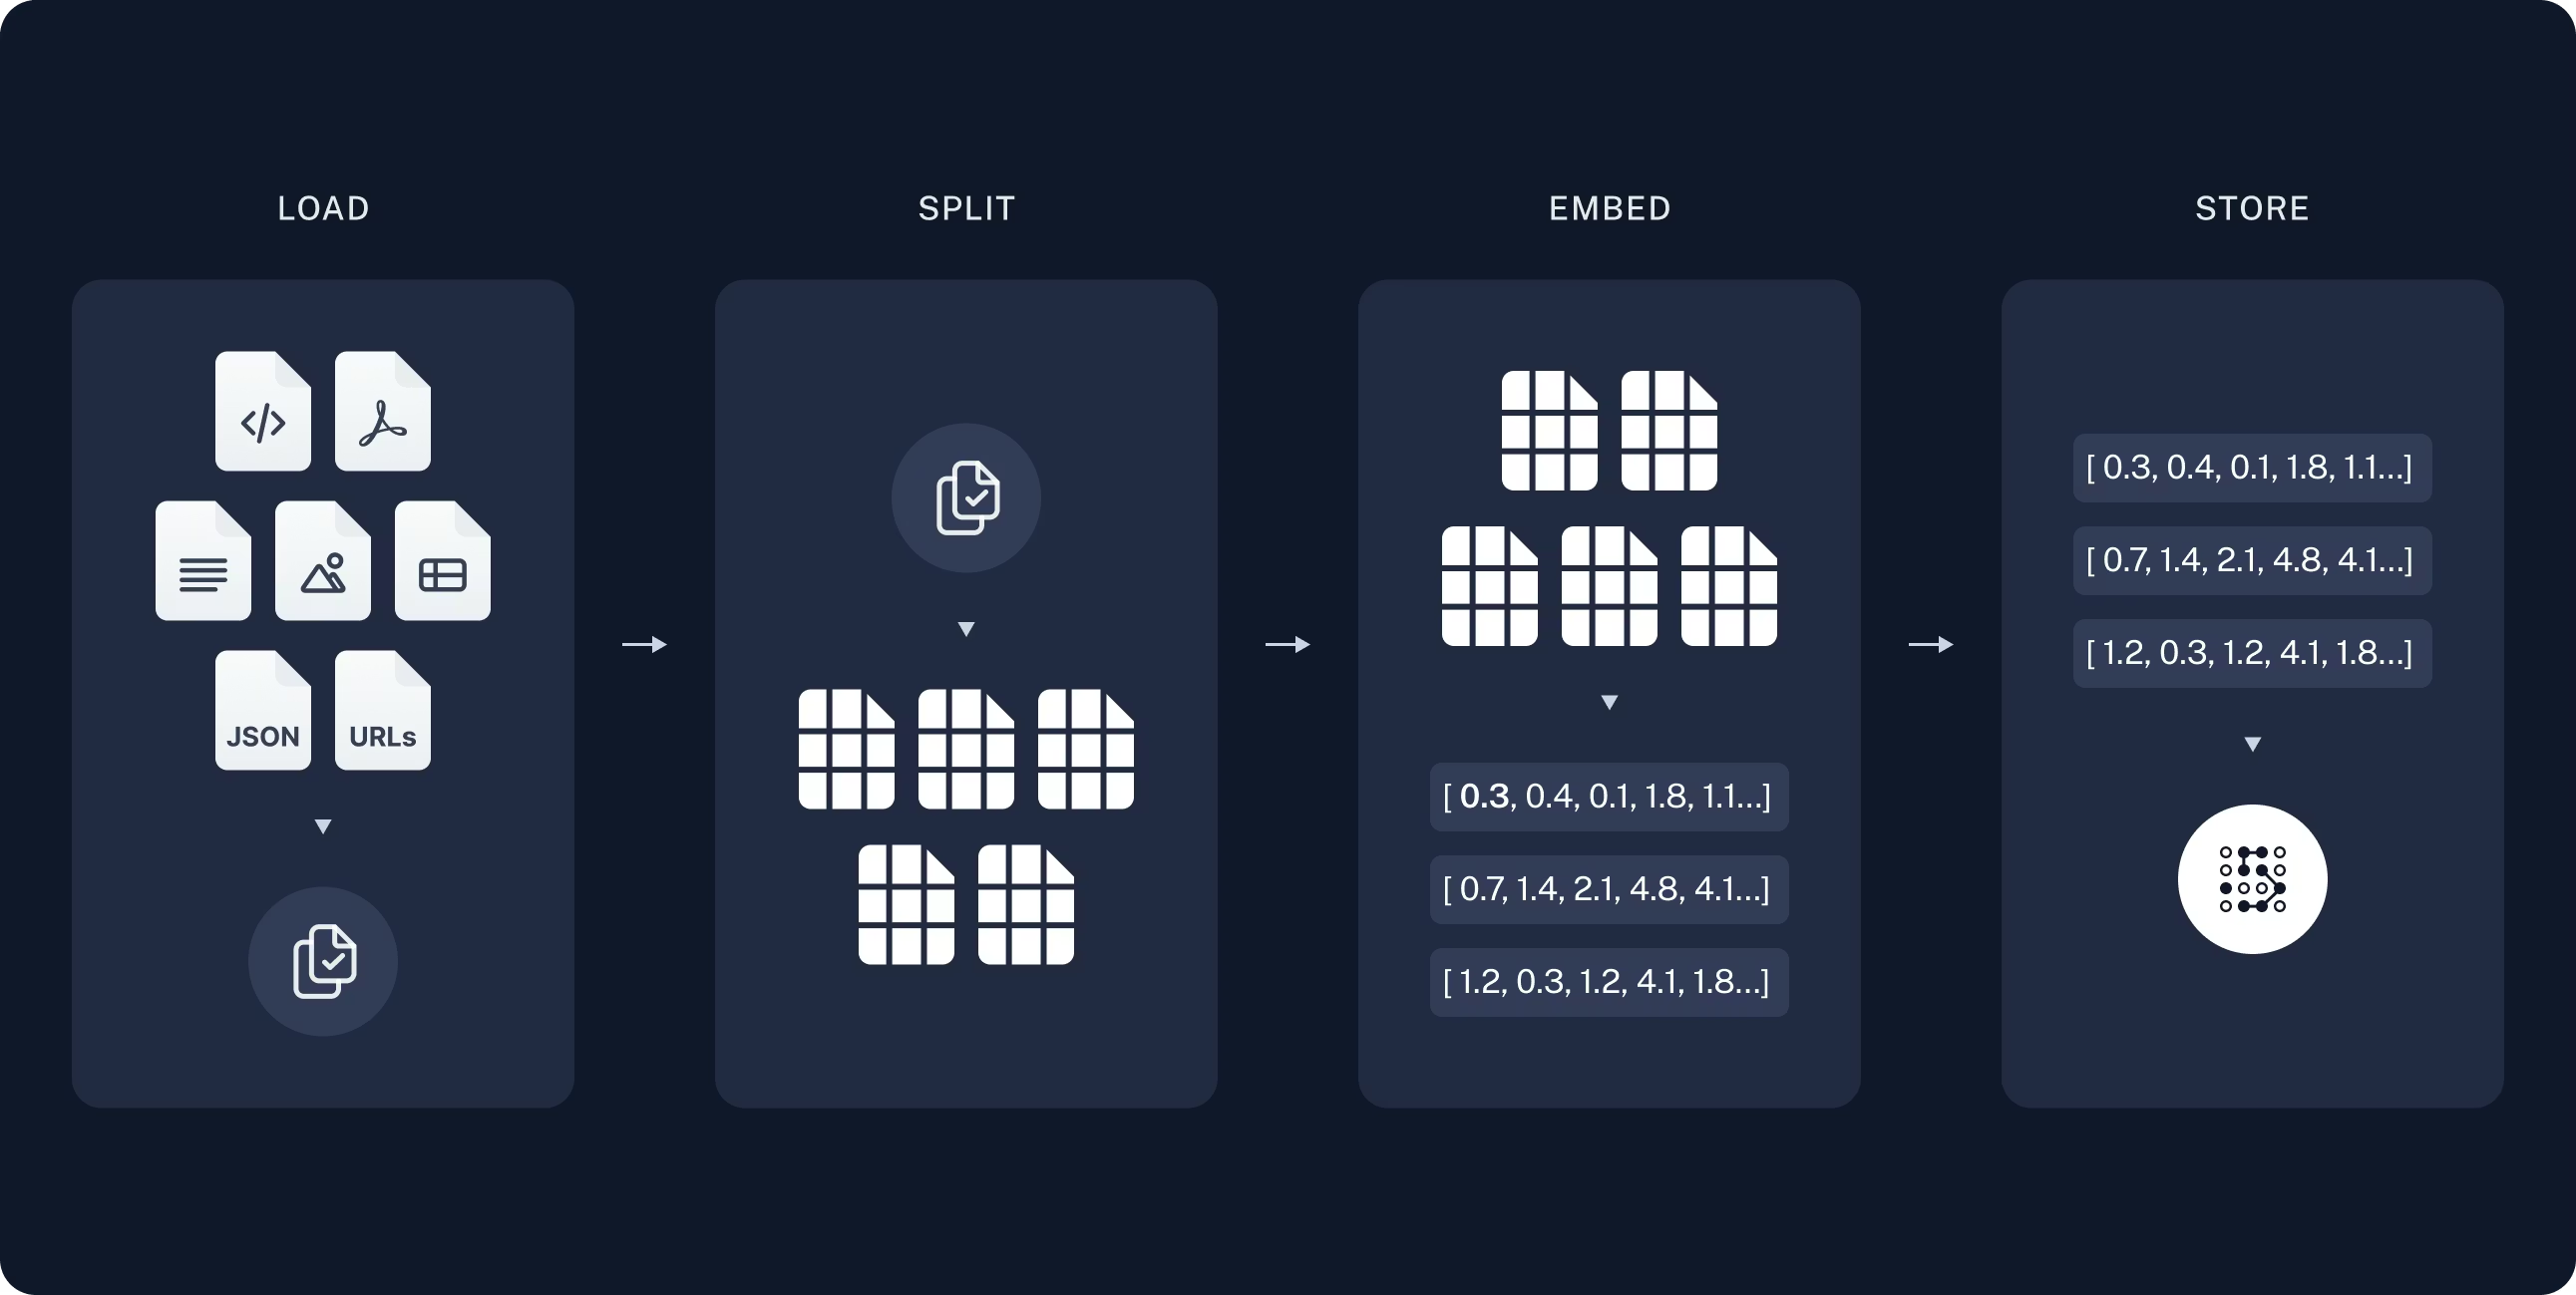

In [ ]:
# Loading Documents

import bs4
from langchain_community.document_loaders import WebBaseLoader

# using  the WebBaseLoader, which uses "urllib" to load HTML from web URLs and "BeautifulSoup" to parse it to text

# Only keep post title, headers, and content from the full HTML.
bs4_strainer = bs4.SoupStrainer(class_=("post-title", "post-header", "post-content"))
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs={"parse_only": bs4_strainer},
)

docs = loader.load()

assert len(docs) == 1
print(f"Total characters: {len(docs[0].page_content)}")

Total characters: 43047


In [11]:
print(docs[0].page_content[:500])



      LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.
Agent System Overview#
In


`TextSplitter`: Object that splits a list of Document objects into smaller chunks for storage and retrieval

In [12]:
# Splitting documents
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # chunk size (characters)
    chunk_overlap=200,  # chunk overlap (characters)
    add_start_index=True,  # track index in original document
)

all_splits = text_splitter.split_documents(docs)

print(f"Split blog post into {len(all_splits)} sub-documents.")

Split blog post into 63 sub-documents.


In [ ]:
# Storing documents (in vector db after embedding)
document_ids = vector_store.add_documents(documents=all_splits)

print(document_ids[:3])

['f7356397-0d40-4daf-995f-7b35ed098fba', '77f846d1-f51d-4331-9c32-a4709cdba79a', '1e8d2011-a539-418c-947d-cd1e4c8989f4']


## Retrieval and Generation

RAG applications commonly work as follows:

1. **Retrieve** : 
Given a user input, relevant splits are retrieved from storage using a Retriever.

2. **Generate** : 
A model produces an answer using a prompt that includes both the question with the retrieved data.

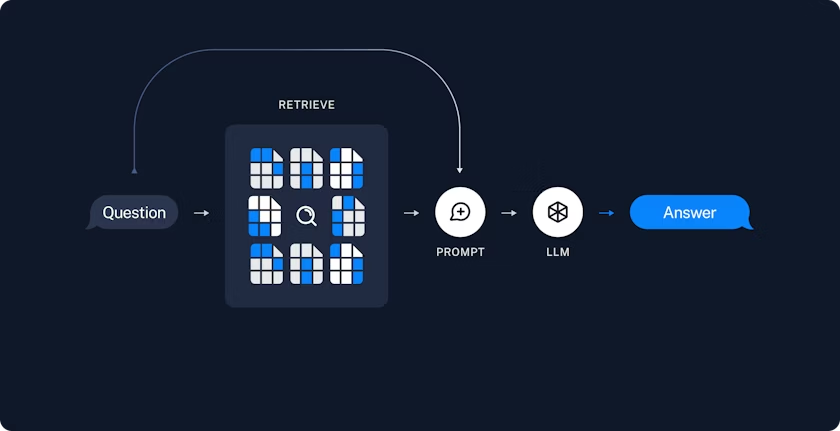

In [14]:
from langchain.tools import tool

@tool(response_format="content_and_artifact")
def retrieve_context(query: str):
    """Retrieve information to help answer a query."""
    retrieved_docs = vector_store.similarity_search(query, k=2)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

In [1]:
# constructing agent , pass the tools create4d
from langchain.agents import create_agent


tools = [retrieve_context]
# instruction to agent
prompt = (
    "You have access to a tool that retrieves context from a blog post. "
    "Use the tool to help answer user queries."
)
agent = create_agent(model, tools, system_prompt=prompt)

ModuleNotFoundError: No module named 'langchain'

In [ ]:
# example 

# list of quries
query = (
    "What is the standard method for Task Decomposition?\n\n"
    "Once you get the answer, look up common extensions of that method."
)

for event in agent.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",
):
    event["messages"][-1].pretty_print()

### Rag Chains


RAG (Retrieval Augmented Generation) chains have a trade-off between flexibility and control. The two main approaches are:

**Agentic RAG**
- **Benefits**:
  - Search only when needed – The LLM can handle greetings, follow-ups, and simple queries without triggering unnecessary searches[5]
  - Contextual search queries – By treating search as a tool with a query input, the LLM crafts its own queries that incorporate conversational context[5]
  - Multiple searches allowed – The LLM can execute several searches in support of a single user query[5]

- **Drawbacks**:
  - Two inference calls – When a search is performed, it requires one call to generate the query and another to produce the final response[5]
  - Reduced control – The LLM may skip searches when they are actually needed, or issue extra searches when unnecessary[5]

**Two-Step RAG Chain**
A Two-Step RAG chain is a retrieval-augmented generation approach where:

1. Always perform a search - The system runs a semantic search on the user query
2. Single LLM call - The retrieved context is directly incorporated into a prompt for a single LLM inference call

- **Benefits**:
  - Single inference call per query – Results in reduced latency[5]
  - Fast and effective method for simple queries[5]

- **Drawbacks**:
  - Less flexible – The LLM doesn't have discretion in deciding whether to perform a search[5]
  - Reduced control – The LLM may not skip searches when they are not needed[5]

The choice between these approaches depends on the specific use case and whether flexibility or speed is more important[5].

In [21]:
from langchain.agents.middleware import dynamic_prompt, ModelRequest

@dynamic_prompt
def prompt_with_context(request: ModelRequest) -> str:
    """Inject context into state messages."""
    last_query = request.state["messages"][-1].text
    retrieved_docs = vector_store.similarity_search(last_query)

    docs_content = "\n\n".join(doc.page_content for doc in retrieved_docs)

    system_message = (
        "You are a helpful assistant. Use the following context in your response:"
        f"\n\n{docs_content}"
    )

    return system_message


agent = create_agent(model, tools=[], middleware=[prompt_with_context])

In [ ]:
# usage
query = "What is task decomposition?"
for step in agent.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()